# Homework 5 - Exercise 3

Extracted from `HW5_completed.ipynb`. This notebook contains only Exercise 3 plus the shared helper cell needed to run it independently.

In [1]:
import os
import random

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

GLOBAL_SEED = 3


def configure_runtime(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)


def load_mnist():
    (train_images, train_labels), _ = keras.datasets.mnist.load_data()
    train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0
    return train_images, train_labels


def build_mnist_model(model_kind, learning_rate=None):
    tf.keras.backend.clear_session()
    if model_kind == "sweep":
        model = keras.Sequential(
            [
                layers.Input(shape=(28 * 28,)),
                layers.Dense(512, activation="relu"),
                layers.Dense(10, activation="softmax"),
            ]
        )
        optimizer = keras.optimizers.RMSprop(learning_rate=learning_rate)
    elif model_kind == "small":
        model = keras.Sequential([layers.Input(shape=(28 * 28,)), layers.Dense(10, activation="softmax")])
        optimizer = keras.optimizers.RMSprop()
    elif model_kind == "large":
        model = keras.Sequential(
            [
                layers.Input(shape=(28 * 28,)),
                layers.Dense(96, activation="relu"),
                layers.Dense(96, activation="relu"),
                layers.Dense(10, activation="softmax"),
            ]
        )
        optimizer = keras.optimizers.RMSprop()
    else:
        raise ValueError(model_kind)

    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


def train_mnist_model(train_images, train_labels, model_kind, epochs, seed, learning_rate=None):
    tf.keras.utils.set_random_seed(seed)
    model = build_mnist_model(model_kind=model_kind, learning_rate=learning_rate)
    history = model.fit(
        train_images,
        train_labels,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=0,
    )
    return history


def summarize_history(history):
    val_loss = history.history["val_loss"]
    val_accuracy = history.history["val_accuracy"]
    return {
        "best_val_loss": float(min(val_loss)),
        "best_epoch": int(np.argmin(val_loss) + 1),
        "best_val_accuracy": float(max(val_accuracy)),
        "final_val_loss": float(val_loss[-1]),
        "final_val_accuracy": float(val_accuracy[-1]),
    }


configure_runtime()


## Exercise 3


In [2]:
# Load MNIST once and reuse it across all model-tuning experiments.
train_images, train_labels = load_mnist()
learning_rates = [1.0, 0.5, 0.1, 0.01, 0.001]

lr_histories = {}
lr_summary = {}
for offset, lr in enumerate(learning_rates):
    # Re-train the same architecture at each learning rate so the effect of alpha
    # can be observed directly from the validation-loss curves.
    history = train_mnist_model(
        train_images,
        train_labels,
        model_kind="sweep",
        epochs=10,
        seed=GLOBAL_SEED + 100 + offset,
        learning_rate=lr,
    )
    lr_histories[lr] = history
    lr_summary[lr] = summarize_history(history)

lr_summary


{1.0: {'best_val_loss': 2.1434545516967773,
  'best_epoch': 9,
  'best_val_accuracy': 0.19300000369548798,
  'final_val_loss': 2.1921558380126953,
  'final_val_accuracy': 0.17341665923595428},
 0.5: {'best_val_loss': 1.7413551807403564,
  'best_epoch': 10,
  'best_val_accuracy': 0.3644999861717224,
  'final_val_loss': 1.7413551807403564,
  'final_val_accuracy': 0.35741665959358215},
 0.1: {'best_val_loss': 0.4784741997718811,
  'best_epoch': 8,
  'best_val_accuracy': 0.9277499914169312,
  'final_val_loss': 0.5496373772621155,
  'final_val_accuracy': 0.921833336353302},
 0.01: {'best_val_loss': 0.13858790695667267,
  'best_epoch': 1,
  'best_val_accuracy': 0.971916675567627,
  'final_val_loss': 0.26256486773490906,
  'final_val_accuracy': 0.9694166779518127},
 0.001: {'best_val_loss': 0.07494605332612991,
  'best_epoch': 6,
  'best_val_accuracy': 0.9782500267028809,
  'final_val_loss': 0.08032749593257904,
  'final_val_accuracy': 0.9782500267028809}}

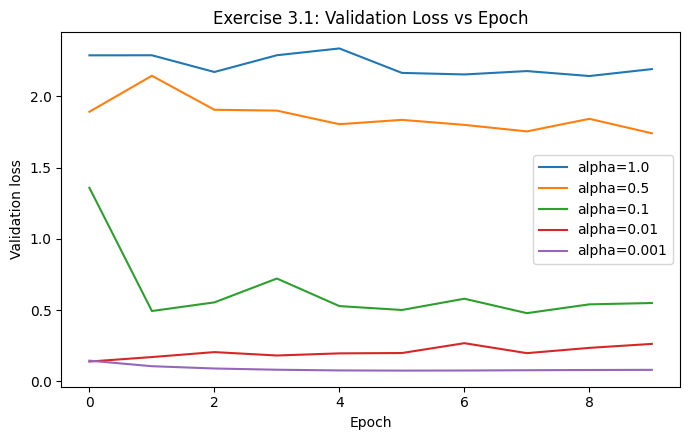

In [3]:
# Plot only validation loss here because that is the metric explicitly requested
# in Exercise 3.1 for comparing learning rates.
plt.figure(figsize=(7, 4.5))
for lr in learning_rates:
    plt.plot(lr_histories[lr].history["val_loss"], label=f"alpha={lr}")
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.1: Validation Loss vs Epoch")
plt.legend()
plt.tight_layout()
# plt.savefig("ex3_learning_rate_sweep.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.1 answer.**

Best validation results from the sweep:

| Learning rate | Best val. loss | Best epoch | Best val. accuracy |
| --- | ---: | ---: | ---: |
| 1.0 | 2.1435 | 9 | 0.1930 |
| 0.5 | 1.7414 | 10 | 0.3645 |
| 0.1 | 0.4785 | 8 | 0.9277 |
| 0.01 | 0.1386 | 1 | 0.9719 |
| 0.001 | 0.07495 | 6 | 0.9783 |

As the learning rate decreases, training becomes much more stable and the validation loss improves dramatically. `alpha = 1.0` is too large: the model stays close to chance performance and never settles. `alpha = 0.5` is still too aggressive. `alpha = 0.1` learns, but the validation curve oscillates. `alpha = 0.01` learns very quickly but reaches its best validation loss immediately, suggesting overshooting and early overfitting. Among these trials, `alpha = 0.001` is the best choice.


In [4]:
# Train the small model from Exercise 3.2, which is just multiclass logistic
# regression because there are no hidden layers.
small_history = train_mnist_model(
    train_images,
    train_labels,
    model_kind="small",
    epochs=50,
    seed=GLOBAL_SEED + 200,
)

# Summarize the best and final validation metrics to discuss overfitting.
small_summary = summarize_history(small_history)
small_summary


{'best_val_loss': 0.26352766156196594,
 'best_epoch': 24,
 'best_val_accuracy': 0.9307500123977661,
 'final_val_loss': 0.26692044734954834,
 'final_val_accuracy': 0.9292500019073486}

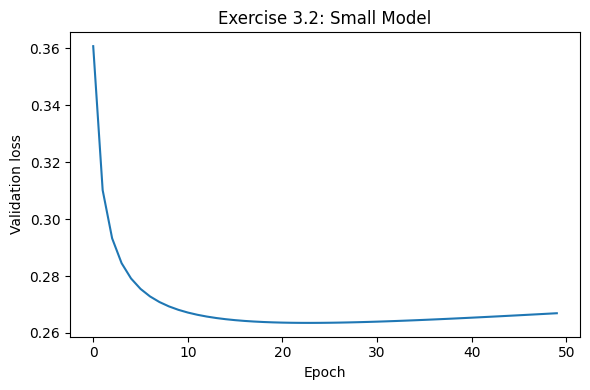

In [5]:
# Plot the small model's validation loss over time to look for a clear minimum.
plt.figure(figsize=(6, 4))
plt.plot(small_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.2: Small Model")
plt.tight_layout()
# plt.savefig("ex3_small_model.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.2 answer.** For the logistic-regression model, the best validation loss was `0.2635` at epoch `24`, while the final validation loss after 50 epochs was `0.2669`. That increase is very small, so there is **not** a sharp, well-defined overfitting threshold here. The minimum is broad and shallow.


In [6]:
# Train the larger model from Exercise 3.3 so we can compare its validation-loss
# behavior to the much smaller logistic-regression baseline.
large_history = train_mnist_model(
    train_images,
    train_labels,
    model_kind="large",
    epochs=50,
    seed=GLOBAL_SEED + 201,
)

# Again, keep the best epoch information for the written discussion.
large_summary = summarize_history(large_history)
large_summary


{'best_val_loss': 0.10384414345026016,
 'best_epoch': 8,
 'best_val_accuracy': 0.9786666631698608,
 'final_val_loss': 0.19578027725219727,
 'final_val_accuracy': 0.9785000085830688}

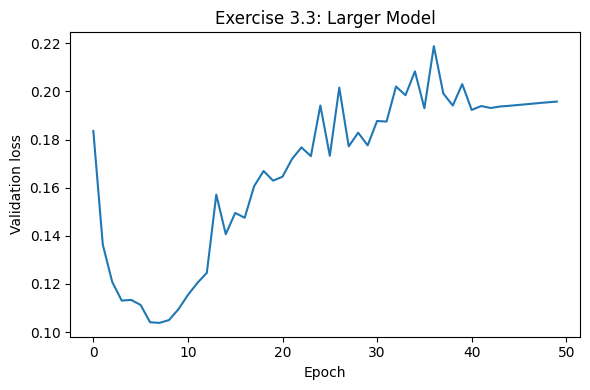

In [7]:
# The larger model should overfit more visibly, so the validation-loss curve is the
# main diagnostic plot for this exercise.
plt.figure(figsize=(6, 4))
plt.plot(large_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Validation loss")
plt.title("Exercise 3.3: Larger Model")
plt.tight_layout()
# plt.savefig("ex3_large_model.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 3.3 answer.** For the larger network, the best validation loss was `0.1038` at epoch `8`, but it increased to `0.1958` by epoch `50`. This model shows a much clearer overfitting region: after about epoch `8`, the model continues fitting the training data while validation loss degrades noticeably. The validation accuracy stays high, which is a good reminder that loss can reveal overconfident mistakes that accuracy hides.
